<a href="https://colab.research.google.com/github/Abdulrahman-Mahmoud-12/ENDO-X/blob/osama/ENDOX_Detection_YOLOv8_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ENDO-X — Polyp Detection Training
## Dataset: Kvasir-SEG | Model: YOLOv8m
---
**Structure بعد الـ extraction:**
```
kvasir/Kvasir-SEG/Kvasir-SEG/
    images/          ← صور المنظار
    bbox/            ← CSV file لكل صورة (class_name,xmin,ymin,xmax,ymax)
    masks/           ← للـ segmentation (مش محتاجينها هنا)
```

## Cell 1 — Install YOLOv8 & Download Dataset

In [1]:
!pip install ultralytics -q

import os
import zipfile

# ── ارفع kaggle.json من Files panel على الشمال قبل ما تشغل ──
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

dataset_id = 'debeshjha1/kvasirseg'
!kaggle datasets download -d {dataset_id}

with zipfile.ZipFile('kvasirseg.zip', 'r') as zip_ref:
  zip_ref.extractall('kvasir')

print('تم التحميل بنجاح')
print(os.listdir('kvasir/Kvasir-SEG/Kvasir-SEG'))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.3/65.3 kB 4.0 MB/s eta 0:00:00
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/debeshjha1/kvasirseg
License(s): copyright-authors
100% 144M/144M [00:07<00:00, 19.1MB/s]

تم التحميل بنجاح
['annotated_images', 'masks', 'images', 'bbox', '1911.07069.pdf']


## Cell 2 — Import Libraries

In [2]:
import os
import cv2
import csv
import shutil
import random
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from ultralytics import YOLO

import torch
print('PyTorch version :', torch.__version__)
print('GPU available   :', torch.cuda.is_available())
if torch.cuda.is_available():
  print('GPU name        :', torch.cuda.get_device_name(0))

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
PyTorch version : 2.11.0+cu128
GPU available   : True
GPU name        : Tesla T4


## Cell 3 — Load Paths & Verify Structure

In [3]:
# ── المسارات الصحيحة ──
IMAGE_DIR = 'kvasir/Kvasir-SEG/Kvasir-SEG/images'
CSV_DIR   = 'kvasir/Kvasir-SEG/Kvasir-SEG/bbox'

# كل صورة ليها CSV منفصل بنفس الاسم جوه bbox/
all_keys = [f.replace('.jpg', '') for f in os.listdir(IMAGE_DIR) if f.endswith('.jpg')]

print('Total images :', len(all_keys))
print('Sample key   :', all_keys[0])

# تأكد إن الـ CSV موجود وشوف شكله
sample_csv_path = os.path.join(CSV_DIR, all_keys[0] + '.csv')
with open(sample_csv_path, 'r') as f:
  content = f.read()
print('CSV content  :\n', content)

# تأكد إن الـ CSV_DIR فيه نفس عدد الـ images
csv_count = len([f for f in os.listdir(CSV_DIR) if f.endswith('.csv')])
print(f'CSV files    : {csv_count}  |  Images: {len(all_keys)}')

Total images : 1000
Sample key   : cju1bhnfitmge0835ynls0l6b
CSV content  :
 class_name,xmin,ymin,xmax,ymax
polyp,372,226,607,389

CSV files    : 1000  |  Images: 1000


## Cell 4 — Visualize 6 Images with Ground Truth Boxes

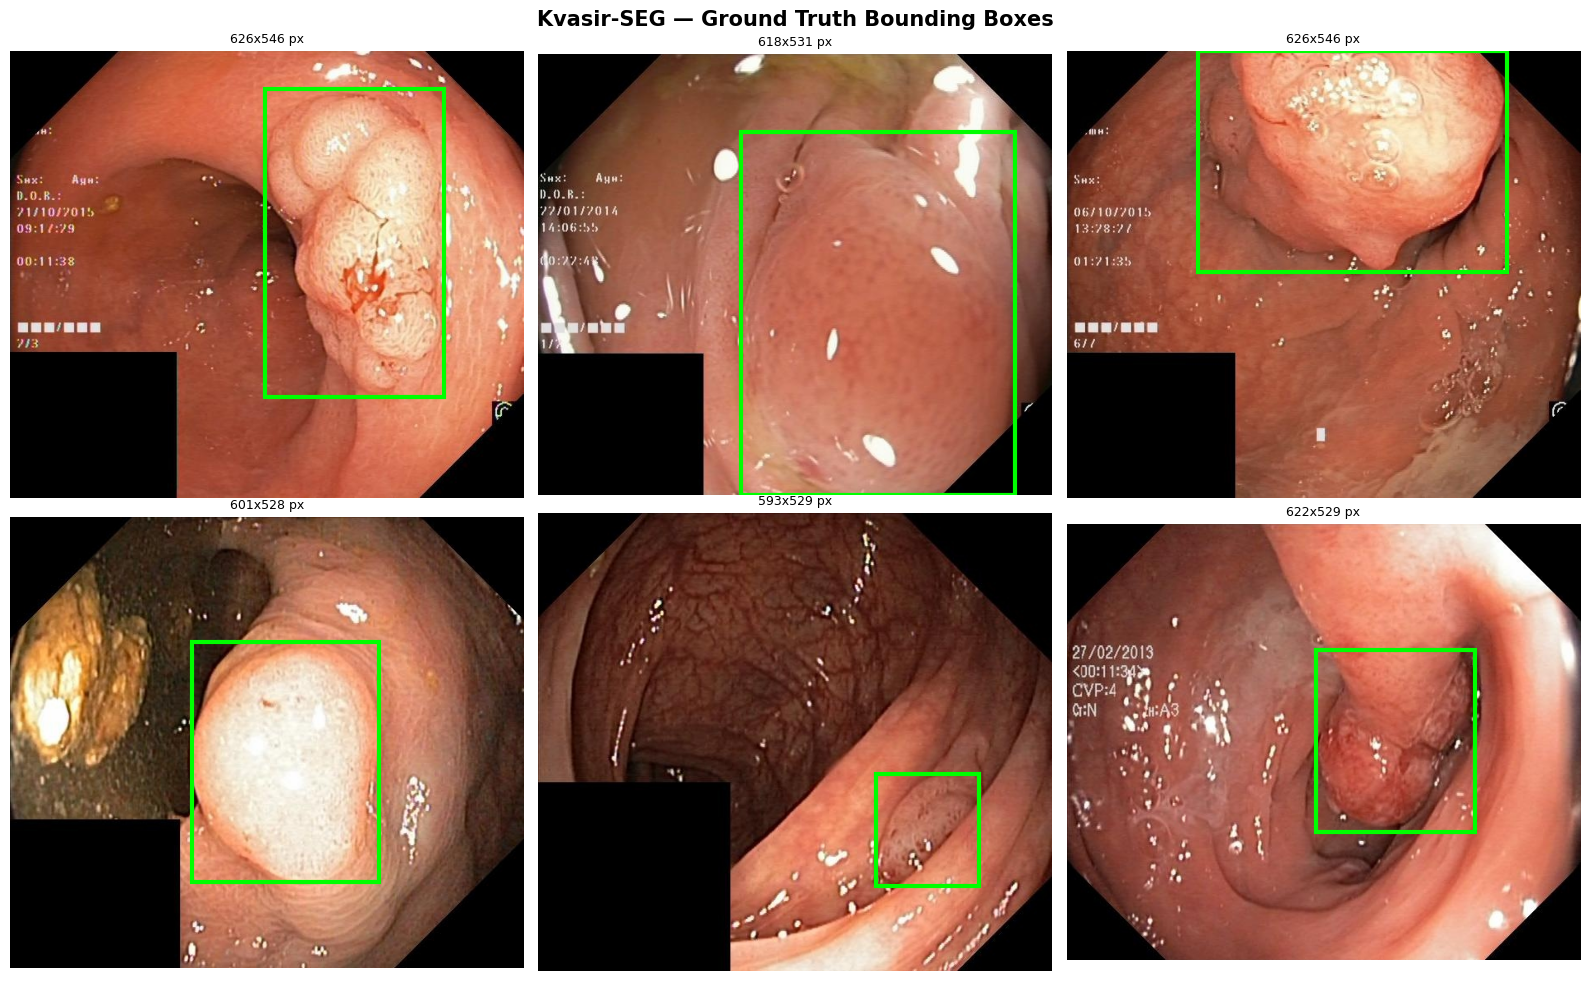

In [4]:
sample_keys = random.sample(all_keys, 6)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Kvasir-SEG — Ground Truth Bounding Boxes', fontsize=15, fontweight='bold')
axes = axes.flatten()

for i, key in enumerate(sample_keys):
  img = cv2.imread(os.path.join(IMAGE_DIR, key + '.jpg'))
  img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

  # قراءة الـ bbox من الـ CSV
  csv_path = os.path.join(CSV_DIR, key + '.csv')
  with open(csv_path, 'r') as f:
    reader = csv.DictReader(f)
    row    = next(reader)

  bx = float(row['xmin'])
  by = float(row['ymin'])
  bw = float(row['xmax']) - bx
  bh = float(row['ymax']) - by

  axes[i].imshow(img)
  rect = patches.Rectangle(
      (bx, by), bw, bh,
      linewidth=3, edgecolor='lime', facecolor='none'
  )
  axes[i].add_patch(rect)
  axes[i].set_title(f'{img.shape[1]}x{img.shape[0]} px', fontsize=9)
  axes[i].axis('off')

plt.tight_layout()
plt.show()

## Cell 5 — Convert Kvasir CSV → YOLO Format
> Kvasir CSV: `class_name, xmin, ymin, xmax, ymax` (absolute pixels)  
> YOLO txt: `class cx cy w h` (normalized 0-1, center-based)

In [5]:
def read_bbox_csv(csv_path, img_w, img_h):
  """
  يقرأ Kvasir CSV ويحوله لـ YOLO format
  CSV columns: class_name, xmin, ymin, xmax, ymax
  """
  with open(csv_path, 'r') as f:
    reader = csv.DictReader(f)
    row    = next(reader)

  x1 = float(row['xmin'])
  y1 = float(row['ymin'])
  x2 = float(row['xmax'])
  y2 = float(row['ymax'])

  bw = x2 - x1
  bh = y2 - y1

  # Center-based normalized
  cx = (x1 + bw / 2) / img_w
  cy = (y1 + bh / 2) / img_h
  nw = bw / img_w
  nh = bh / img_h

  # Clamp to [0, 1]
  cx = max(0., min(1., cx))
  cy = max(0., min(1., cy))
  nw = max(0., min(1., nw))
  nh = max(0., min(1., nh))

  return f'0 {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}'


# Test on one sample
test_key = all_keys[0]
test_img = cv2.imread(os.path.join(IMAGE_DIR, test_key + '.jpg'))
h, w     = test_img.shape[:2]
test_csv = os.path.join(CSV_DIR, test_key + '.csv')

print('Image size :', w, 'x', h)
print('YOLO line  :', read_bbox_csv(test_csv, w, h))
print('\nFormat: 0 cx cy w h  (class=0 → polyp, all values 0-1)')

Image size : 622 x 531
YOLO line  : 0 0.786977 0.579096 0.377814 0.306968

Format: 0 cx cy w h  (class=0 → polyp, all values 0-1)


## Cell 6 — Split Dataset & Build YOLO Folder Structure

In [6]:
# YOLO folder structure
BASE = 'dataset'

for split in ['train', 'val', 'test']:
  os.makedirs(f'{BASE}/images/{split}', exist_ok=True)
  os.makedirs(f'{BASE}/labels/{split}', exist_ok=True)

# 70% train | 15% val | 15% test
train_keys, temp_keys = train_test_split(all_keys, test_size=0.30, random_state=42)
val_keys,   test_keys = train_test_split(temp_keys, test_size=0.50, random_state=42)

print(f'Train : {len(train_keys)} images')
print(f'Val   : {len(val_keys)}   images')
print(f'Test  : {len(test_keys)}  images')

def build_split(keys, split_name):
  for key in keys:
    img_path = os.path.join(IMAGE_DIR, key + '.jpg')
    csv_path = os.path.join(CSV_DIR,   key + '.csv')

    # Image size for normalization
    img  = cv2.imread(img_path)
    h, w = img.shape[:2]

    # Copy image
    shutil.copy(img_path, f'{BASE}/images/{split_name}/{key}.jpg')

    # Write YOLO label
    yolo_line = read_bbox_csv(csv_path, w, h)
    with open(f'{BASE}/labels/{split_name}/{key}.txt', 'w') as f:
      f.write(yolo_line + '\n')

print('\nBuilding splits...')
build_split(train_keys, 'train')
build_split(val_keys,   'val')
build_split(test_keys,  'test')

print('\nDataset ready!')
print('images/train :', len(os.listdir(f'{BASE}/images/train')))
print('labels/train :', len(os.listdir(f'{BASE}/labels/train')))
print('images/val   :', len(os.listdir(f'{BASE}/images/val')))
print('images/test  :', len(os.listdir(f'{BASE}/images/test')))

Train : 700 images
Val   : 150   images
Test  : 150  images

Building splits...

Dataset ready!
images/train : 700
labels/train : 700
images/val   : 150
images/test  : 150


## Cell 7 — Create dataset.yaml

In [7]:
dataset_yaml = {
    'path'  : '/content/dataset',
    'train' : 'images/train',
    'val'   : 'images/val',
    'test'  : 'images/test',
    'nc'    : 1,
    'names' : ['polyp']
}

yaml_path = 'kvasir_detection.yaml'

with open(yaml_path, 'w') as f:
  yaml.dump(dataset_yaml, f, default_flow_style=False)

with open(yaml_path, 'r') as f:
  print(f.read())

print('dataset.yaml ready')

names:
- polyp
nc: 1
path: /content/dataset
test: images/test
train: images/train
val: images/val

dataset.yaml ready


## Cell 8 — Hyperparameters

In [8]:
MODEL_SIZE  = 'yolov8m.pt'
IMG_SIZE    = 640
EPOCHS      = 80
BATCH_SIZE  = 16
LR0         = 0.01
LRF         = 0.001
PATIENCE    = 20
CONF_THRESH = 0.25
IOU_THRESH  = 0.45

print(f'Model      : {MODEL_SIZE}')
print(f'Image size : {IMG_SIZE}x{IMG_SIZE}')
print(f'Epochs     : {EPOCHS}')
print(f'Batch size : {BATCH_SIZE}')
print(f'LR         : {LR0} → {LRF} (cosine)')
print(f'Patience   : {PATIENCE}')

Model      : yolov8m.pt
Image size : 640x640
Epochs     : 80
Batch size : 16
LR         : 0.01 → 0.001 (cosine)
Patience   : 20


## Cell 9 — Load YOLOv8m

In [9]:
model = YOLO(MODEL_SIZE)

total_params = sum(p.numel() for p in model.model.parameters())
print(f'Model loaded : {MODEL_SIZE}')
print(f'Total params : {total_params:,}')

Model loaded : yolov8m.pt
Total params : 25,902,640


## Cell 10 — Train
> ~25-35 دقيقة على T4 GPU

In [10]:
results = model.train(
    data       = yaml_path,
    epochs     = EPOCHS,
    imgsz      = IMG_SIZE,
    batch      = BATCH_SIZE,
    lr0        = LR0,
    lrf        = LRF,
    patience   = PATIENCE,
    optimizer  = 'Adam',
    cos_lr     = True,
    augment    = True,
    mosaic     = 1.0,
    mixup      = 0.1,
    degrees    = 10.0,
    fliplr     = 0.5,
    flipud     = 0.2,
    hsv_h      = 0.015,
    hsv_s      = 0.7,
    hsv_v      = 0.4,
    conf       = CONF_THRESH,
    iou        = IOU_THRESH,
    save       = True,
    project    = 'ENDOX_runs',
    name       = 'detection',
    verbose    = True
)

print('\nTraining complete!')
print('Best model: ENDOX_runs/detection/weights/best.pt')

Ultralytics 8.4.128 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=0.25, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=kvasir_detection.yaml, degrees=10.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.2, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.45, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.001, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=detection, nbs=64, nms=False, opset=Non

## Cell 11 — Plot Training Curves

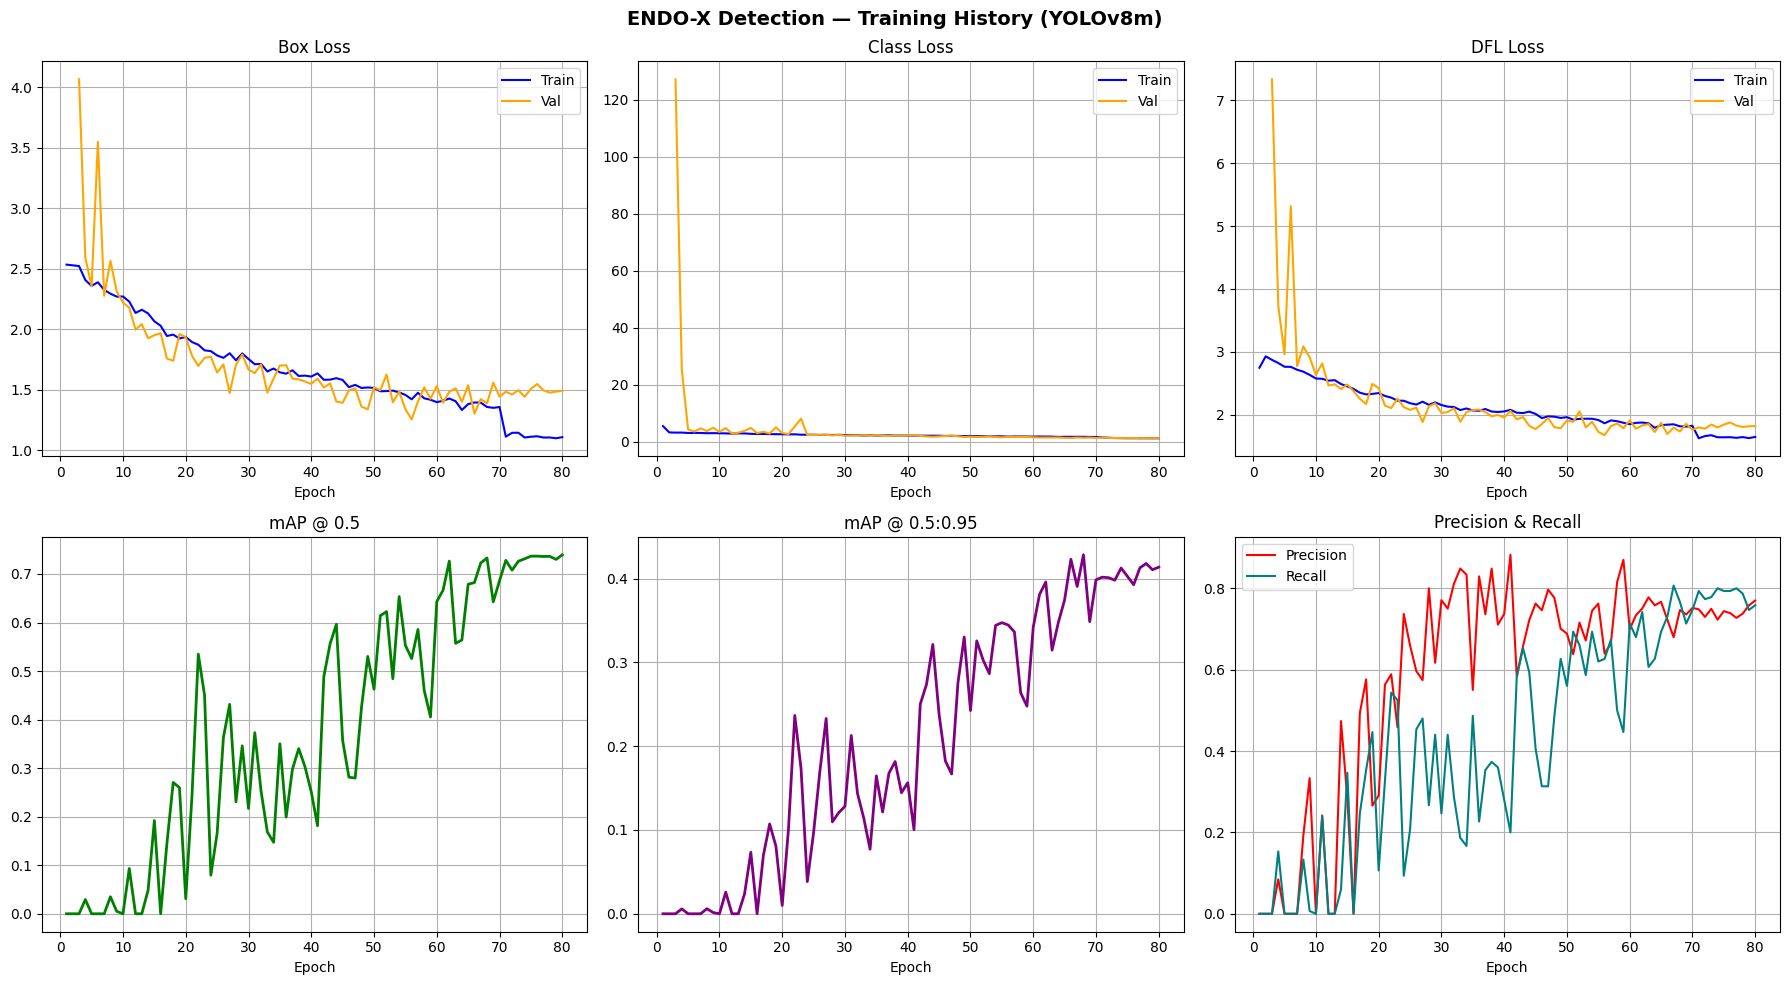

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Corrected path based on your folder structure
csv_path = 'runs/detect/ENDOX_runs/detection/results.csv'

df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

epochs = df['epoch']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('ENDO-X Detection — Training History (YOLOv8m)', fontsize=14, fontweight='bold')

axes[0,0].plot(epochs, df['train/box_loss'], label='Train', color='blue')
axes[0,0].plot(epochs, df['val/box_loss'],   label='Val',   color='orange')
axes[0,0].set_title('Box Loss')
axes[0,0].set_xlabel('Epoch')
axes[0,0].legend()
axes[0,0].grid(True)

axes[0,1].plot(epochs, df['train/cls_loss'], label='Train', color='blue')
axes[0,1].plot(epochs, df['val/cls_loss'],   label='Val',   color='orange')
axes[0,1].set_title('Class Loss')
axes[0,1].set_xlabel('Epoch')
axes[0,1].legend()
axes[0,1].grid(True)

axes[0,2].plot(epochs, df['train/dfl_loss'], label='Train', color='blue')
axes[0,2].plot(epochs, df['val/dfl_loss'],   label='Val',   color='orange')
axes[0,2].set_title('DFL Loss')
axes[0,2].set_xlabel('Epoch')
axes[0,2].legend()
axes[0,2].grid(True)

axes[1,0].plot(epochs, df['metrics/mAP50(B)'], color='green', linewidth=2)
axes[1,0].set_title('mAP @ 0.5')
axes[1,0].set_xlabel('Epoch')
axes[1,0].grid(True)

axes[1,1].plot(epochs, df['metrics/mAP50-95(B)'], color='purple', linewidth=2)
axes[1,1].set_title('mAP @ 0.5:0.95')
axes[1,1].set_xlabel('Epoch')
axes[1,1].grid(True)

axes[1,2].plot(epochs, df['metrics/precision(B)'], label='Precision', color='red')
axes[1,2].plot(epochs, df['metrics/recall(B)'],    label='Recall',    color='teal')
axes[1,2].set_title('Precision & Recall')
axes[1,2].set_xlabel('Epoch')
axes[1,2].legend()
axes[1,2].grid(True)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

## Cell 12 — Evaluate on Test Set

In [14]:
# Corrected path to the weights file
best_model = YOLO('runs/detect/ENDOX_runs/detection/weights/best.pt')

metrics = best_model.val(
    data    = yaml_path,
    split   = 'test',
    imgsz   = IMG_SIZE,
    conf    = CONF_THRESH,
    iou     = IOU_THRESH,
    verbose = True
)

print('\n─── Test Results ───')
print(f'mAP @ 0.5       : {metrics.box.map50:.4f}  ({metrics.box.map50*100:.2f}%)')
print(f'mAP @ 0.5:0.95  : {metrics.box.map:.4f}   ({metrics.box.map*100:.2f}%)')
print(f'Precision       : {metrics.box.mp:.4f}')
print(f'Recall          : {metrics.box.mr:.4f}')

Ultralytics 8.4.128 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.0±0.0 ms, read: 26.6±17.9 MB/s, size: 53.9 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning /content/dataset/labels/test... 150 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 150/150 540.8it/s 0.3s
val: New cache created: /content/dataset/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 2.1it/s 4.8s
                   all        150        150      0.841      0.787      0.752      0.418
Speed: 4.1ms preprocess, 18.7ms inference, 0.0ms loss, 1.8ms postprocess per image
Results saved to /content/runs/detect/val

─── Test Results ───
mAP @ 0.5       : 0.7516  (75.16%)
mAP @ 0.5:0.95  

## Cell 13 — Visualize Predictions on Test Images

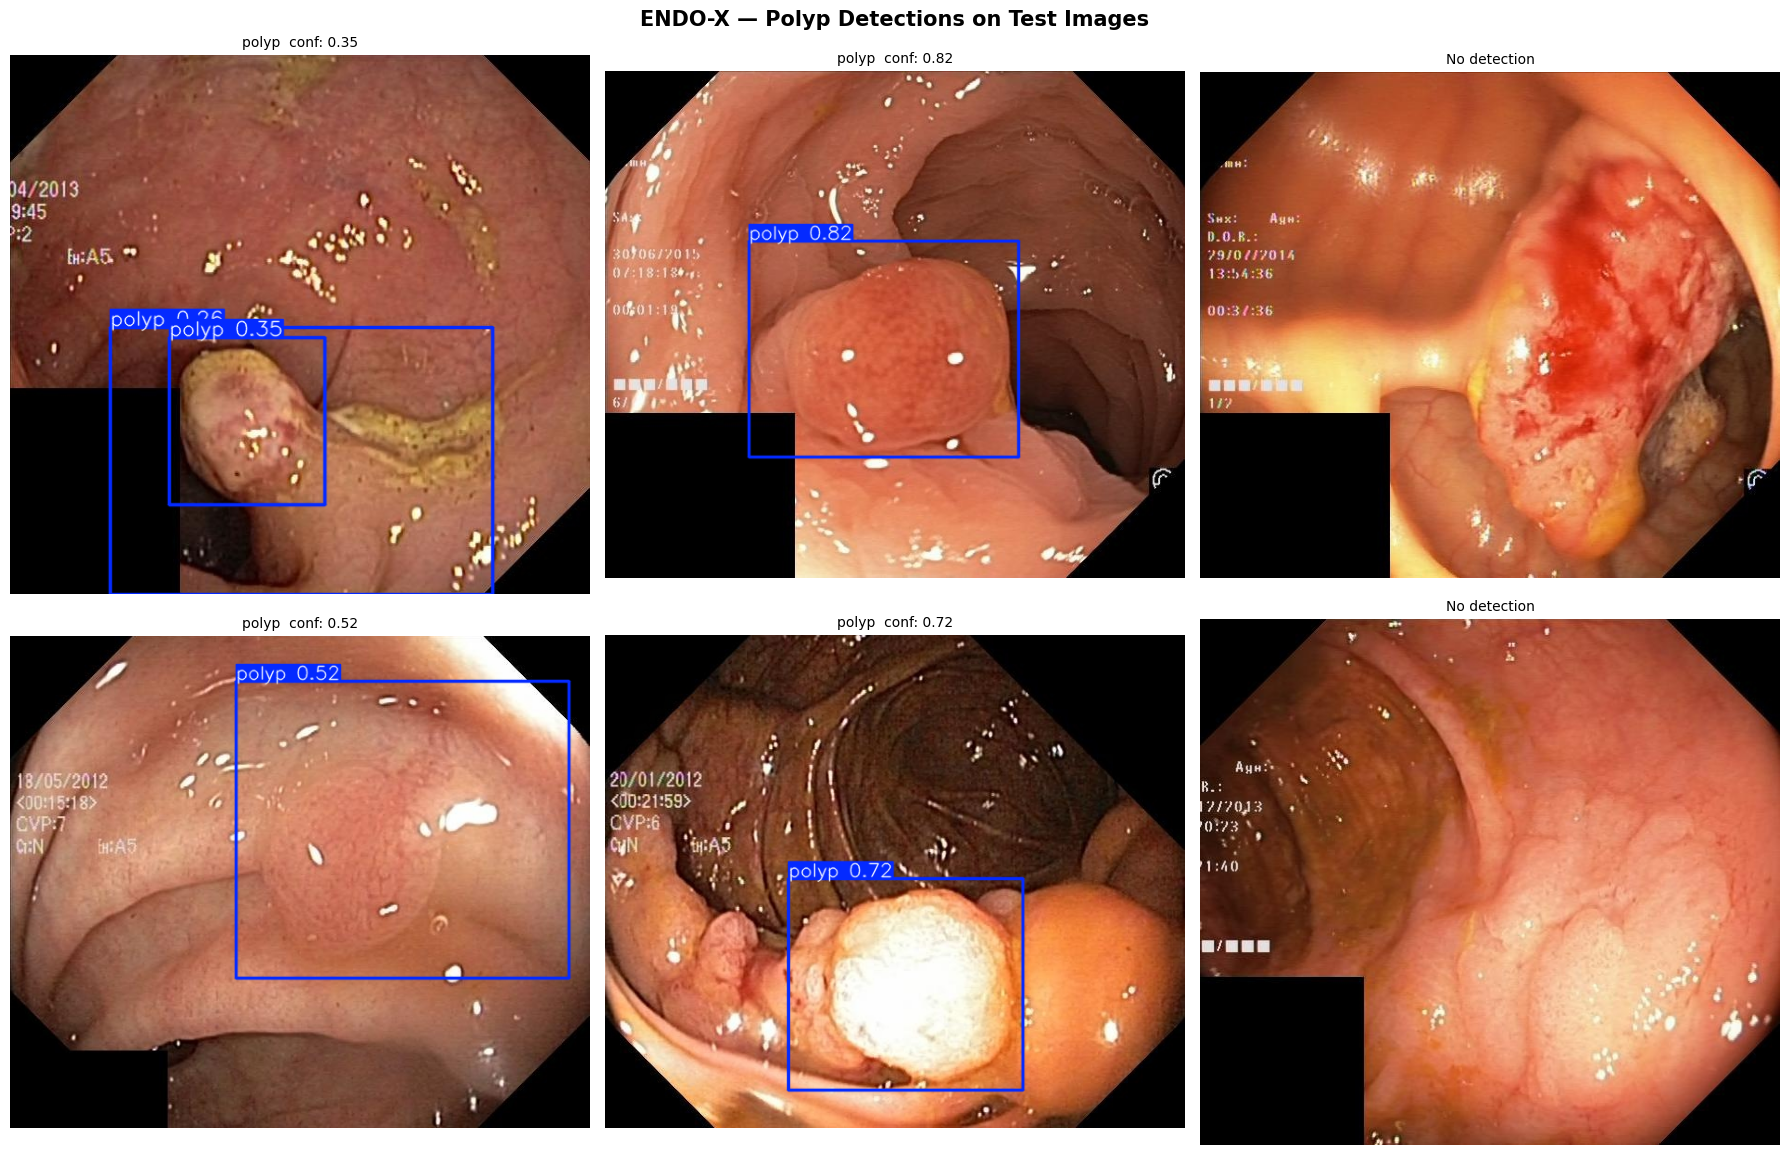

In [15]:
test_img_dir = f'{BASE}/images/test'
test_images  = random.sample(os.listdir(test_img_dir), 6)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('ENDO-X — Polyp Detections on Test Images', fontsize=15, fontweight='bold')
axes = axes.flatten()

for i, fname in enumerate(test_images):
  img_path = os.path.join(test_img_dir, fname)

  result = best_model.predict(
      source  = img_path,
      conf    = CONF_THRESH,
      iou     = IOU_THRESH,
      verbose = False
  )[0]

  plotted = result.plot()
  plotted = cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB)

  boxes = result.boxes
  if len(boxes) > 0:
    conf_val = boxes.conf[0].item()
    title    = f'polyp  conf: {conf_val:.2f}'
  else:
    title = 'No detection'

  axes[i].imshow(plotted)
  axes[i].set_title(title, fontsize=10)
  axes[i].axis('off')

plt.tight_layout()
plt.savefig('test_predictions.png', dpi=150)
plt.show()

## Cell 14 — Confidence Distribution Analysis

Detected      : 135
Not detected  : 15
Detection rate: 90.0%
Mean confidence: 0.6475


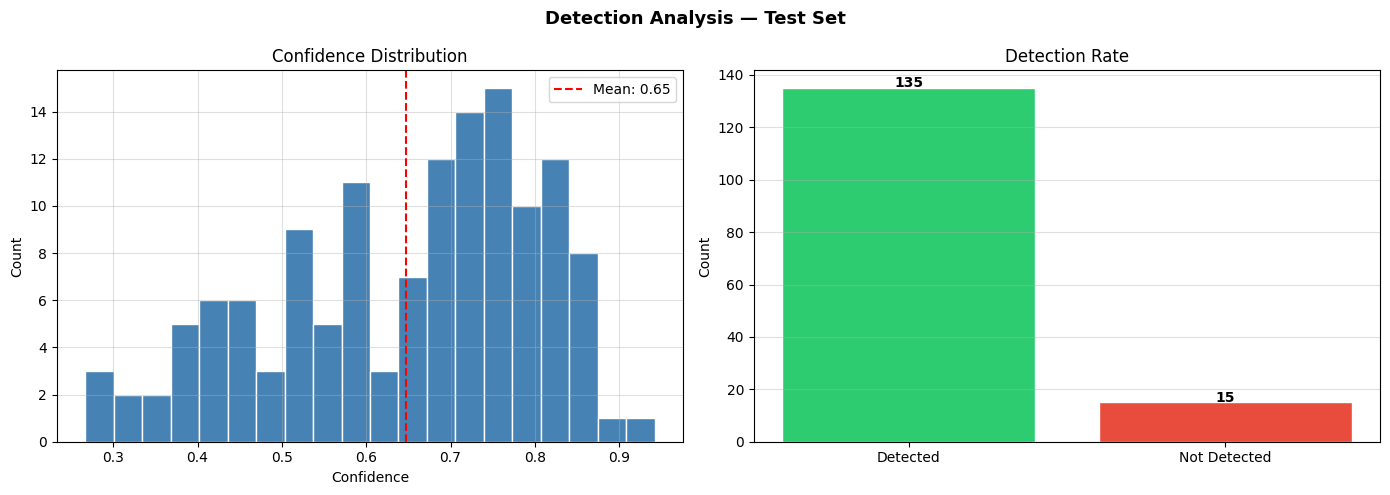

In [16]:
all_confs    = []
detected     = 0
not_detected = 0

for fname in os.listdir(test_img_dir):
  img_path = os.path.join(test_img_dir, fname)
  result   = best_model.predict(
      source  = img_path,
      conf    = CONF_THRESH,
      verbose = False
  )[0]
  boxes = result.boxes

  if len(boxes) > 0:
    all_confs.append(boxes.conf[0].item())
    detected += 1
  else:
    not_detected += 1

print(f'Detected      : {detected}')
print(f'Not detected  : {not_detected}')
print(f'Detection rate: {detected / (detected + not_detected) * 100:.1f}%')
if all_confs:
  print(f'Mean confidence: {np.mean(all_confs):.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Detection Analysis — Test Set', fontsize=13, fontweight='bold')

if all_confs:
  axes[0].hist(all_confs, bins=20, color='steelblue', edgecolor='white')
  axes[0].axvline(np.mean(all_confs), color='red', linestyle='--',
                  label=f'Mean: {np.mean(all_confs):.2f}')
  axes[0].legend()
axes[0].set_title('Confidence Distribution')
axes[0].set_xlabel('Confidence')
axes[0].set_ylabel('Count')
axes[0].grid(True, alpha=0.4)

axes[1].bar(
    ['Detected', 'Not Detected'],
    [detected, not_detected],
    color=['#2ecc71', '#e74c3c'], edgecolor='white'
)
axes[1].set_title('Detection Rate')
axes[1].set_ylabel('Count')
axes[1].grid(True, alpha=0.4, axis='y')
for j, v in enumerate([detected, not_detected]):
  axes[1].text(j, v + 0.3, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('confidence_analysis.png', dpi=150)
plt.show()

## Cell 15 — Save Weights for ENDO-X Backend
> حط الـ `endox_polyp_detector.pt` في `models/detector/` في الـ project

In [18]:
import shutil
from google.colab import files

# Corrected source path to match your Colab folders
shutil.copy(
    'runs/detect/ENDOX_runs/detection/weights/best.pt',
    'endox_polyp_detector.pt'
)
print('Saved: endox_polyp_detector.pt')
print('Put this file in: models/detector/ in the ENDO-X project')

# Download the file to your local machine
files.download('endox_polyp_detector.pt')

Saved: endox_polyp_detector.pt
Put this file in: models/detector/ in the ENDO-X project


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Cell 16 — Test Single Image

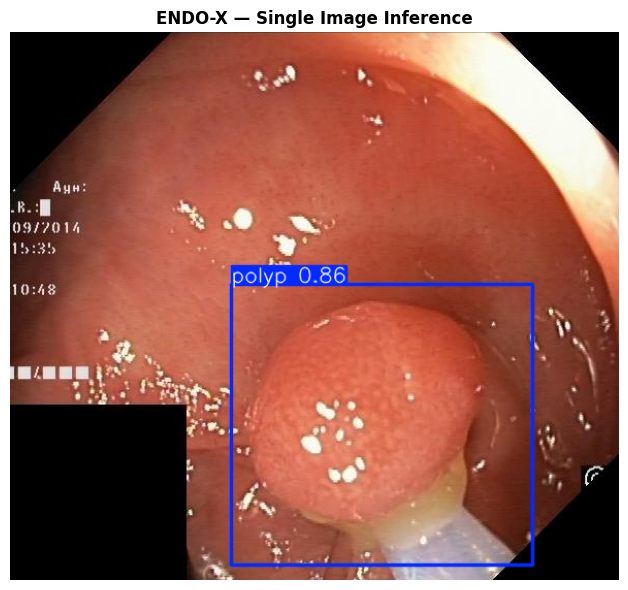

Class      : polyp
Confidence : 0.8600  (86.00%)
Box (xyxy) : x1=214.2  y1=244.4  x2=506.2  y2=516.8


In [20]:
demo_img = os.path.join(test_img_dir, os.listdir(test_img_dir)[0])

result = best_model.predict(
    source  = demo_img,
    conf    = CONF_THRESH,
    iou     = IOU_THRESH,
    verbose = False
)[0]

plotted = result.plot()
plotted = cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(plotted)
plt.title('ENDO-X — Single Image Inference', fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

boxes = result.boxes
if len(boxes) > 0:
  for box in boxes:
    xyxy = box.xyxy[0].tolist()
    conf = box.conf[0].item()
    print(f'Class      : polyp')
    print(f'Confidence : {conf:.4f}  ({conf*100:.2f}%)')
    print(f'Box (xyxy) : x1={xyxy[0]:.1f}  y1={xyxy[1]:.1f}  x2={xyxy[2]:.1f}  y2={xyxy[3]:.1f}')
else:
  print('No polyp detected.')

---
## Summary

| Component | Value |
|-----------|-------|
| Model | YOLOv8m |
| Dataset | Kvasir-SEG (1000 images) |
| Classes | 1 — polyp |
| Annotation format | CSV per image (xmin,ymin,xmax,ymax) |
| Input size | 640×640 |
| Batch size | 16 |
| Optimizer | Adam + cosine LR |
| Augmentation | Mosaic + MixUp + HSV + Flip |
| Early stopping | patience = 20 |
| Expected mAP@0.5 | 0.85 – 0.92 |
| Output file | `endox_polyp_detector.pt` |
| Put it in | `models/detector/` in ENDO-X |